<a href="https://colab.research.google.com/github/christopher-alford/cnn-digit-recognition/blob/main/3010Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy matplotlib tensorflow scikit-learn

In [ ]:
# Importing tyhe libraries needed for data handling, visuals,
# machine learning model, and evaluation

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
# Loading the mnist dataset (handwritten numerical digits)
# Simulation of handwritten numeric entries in medical forms

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Training labels shape: (60000,)
Test labels shape: (10000,)


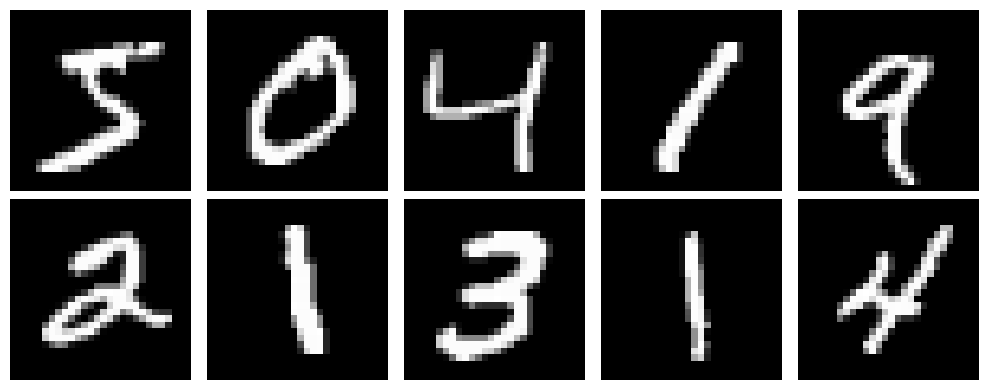

In [ ]:
#Sample images to show the dataset is loaded properly

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Class distribution checks

unique, counts = np.unique(y_train, return_counts=True)
print("\nClass distribution in the training set:")
for digit, count in zip(unique, counts):
    print(f"Digit {digit}: {count}")



Class distribution in the training set:
Digit 0: 5923
Digit 1: 6742
Digit 2: 5958
Digit 3: 6131
Digit 4: 5842
Digit 5: 5421
Digit 6: 5918
Digit 7: 6265
Digit 8: 5851
Digit 9: 5949


In [ ]:
# Preprocess data for Logistic Regression and flatten 28x28
# images into 784 features. Normalize pixel values to [0, 1]

X_train_flat = X_train.reshape(X_train.shape[0], 28 * 28) / 255.0
X_test_flat = X_test.reshape(X_test.shape[0], 28 * 28) / 255.0
print("\nFlattened training data shape:", X_train_flat.shape)
print("Flattened test data shape:", X_test_flat.shape)


Flattened training data shape: (60000, 784)
Flattened test data shape: (10000, 784)


In [ ]:
#Logistic Regression baseline model

print("\nLogistic Regression Model: ")
log_reg = LogisticRegression(
    max_iter = 1000,
    solver = 'lbfgs',
    multi_class = 'multinomial'
)

log_reg.fit(X_train_flat, y_train)

y_pred_lr = log_reg.predict(X_test_flat)

print("\n Logistic Regression Results: ")
print("Accuracy: ", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report: ")
print(classification_report(y_test, y_pred_lr))

print("Confusion Matrix: ")
print(confusion_matrix(y_test, y_pred_lr))



Logistic Regression Model: 


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



 Logistic Regression Results: 
Accuracy:  0.9259

Classification Report: 
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.92      1032
           3       0.90      0.91      0.91      1010
           4       0.94      0.94      0.94       982
           5       0.89      0.87      0.88       892
           6       0.94      0.95      0.95       958
           7       0.93      0.92      0.93      1028
           8       0.88      0.88      0.88       974
           9       0.91      0.92      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.93      0.93      0.93     10000

Confusion Matrix: 
[[ 958    0    1    3    1    9    4    3    1    0]
 [   0 1111    5    2    0    2    3    1   11    0]
 [   6    9  931   16   10    3   12   10

In [ ]:
# Start preprocessing for the Convolutional Nueral Network
# Preserve image structure for spatial feature learning

X_train_cnn = X_train.astype("float32") / 255.0
X_test_cnn = X_test.astype("float32") / 255.0

X_train_cnn = X_train_cnn.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_cnn.reshape(-1, 28, 28, 1)

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("\nCNN training data shape:", X_train_cnn.shape)
print("CNN test data shape:", X_test_cnn.shape)


CNN training data shape: (60000, 28, 28, 1)
CNN test data shape: (10000, 28, 28, 1)


In [ ]:
# CNN Model Build
# Convolutional layers detect patterns

cnn_model = Sequential([
    Conv2D( 32, kernel_size =(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nCNN Model Summary: ")
cnn_model.summary()


CNN Model Summary: 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#CNN Model Train

history = cnn_model.fit(
    X_train_cnn,
    y_train_cat,
    validation_split=0.1,
    epochs=5,
    batch_size=128,
    verbose=1
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 98ms/step - accuracy: 0.9171 - loss: 0.2716 - val_accuracy: 0.9822 - val_loss: 0.0615
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 78s 89ms/step - accuracy: 0.9761 - loss: 0.0788 - val_accuracy: 0.9873 - val_loss: 0.0442
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - accuracy: 0.9823 - loss: 0.0576 - val_accuracy: 0.9893 - val_loss: 0.0357
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 86ms/step - accuracy: 0.9867 - loss: 0.0439 - val_accuracy: 0.9898 - val_loss: 0.0373
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 37s 88ms/step - accuracy: 0.9881 - loss: 0.0376 - val_accuracy: 0.9913 - val_loss: 0.0333


In [ ]:
# Model Evaluation

test_loss, test_accuracy = cnn_model.evaluate(X_test_cnn, y_test_cat, verbose = 0)

print("\n CNN Results ")
print("Test Accuracy: ", test_accuracy)
print("Test Loss: ", test_loss)

y_pred_probs = cnn_model.predict(X_test_cnn)
y_pred_cnn = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_cnn))   # <---- F1 Score found here

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_cnn))


 CNN Results 
Test Accuracy:  0.9907000064849854
Test Loss:  0.02715427801012993
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      1.00      0.99      1032
           3       1.00      0.99      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

Confusion Matrix:
[[ 975    0    2    0    0    0    0    2    1    0]
 [   0 1131    0    0  

In [ ]:
# Plotting the training history

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Training vs Validation Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Training vs Validation Loss')
plt.legend()
plt.show()

In [ ]:
# Misclasification examples

misclassified_indices = np.where(y_pred_cnn != y_test)[0]

plt.figure(figsize=(10, 8))
for i, idx in enumerate(misclassified_indices[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[idx], cmap="gray")
    plt.title(f"True: {y_test[idx]}, Pred: {y_pred_cnn[idx]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Error Detection System
# Flags low-confidence predictions for review
# Simulates real-world medical data validation

def predict_with_error_detection(model, X, threshold=0.90):
    predictions = model.predict(X)

    results = []

    for probs in predictions:
        digit = np.argmax(probs)
        confidence = np.max(probs)

        if confidence < threshold:
            status = "Review Needed"
        else:
            status = "Accepted"

        results.append({
            "digit": digit,
            "confidence": confidence,
            "status": status
        })

    return results

In [ ]:
results = predict_with_error_detection(cnn_model, X_test_cnn[:10])

for r in results:
    print(r)

In [ ]:
# Showing the flagged images
# Helps interpret why model is uncertain

results = predict_with_error_detection(cnn_model, X_test_cnn, threshold=0.80)

flagged_indices = [i for i, r in enumerate(results) if r["status"] == "Review Needed"]

plt.figure(figsize=(10, 8))

for i, idx in enumerate(flagged_indices[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[idx], cmap="gray")
    plt.title(f"True: {y_test[idx]}\nPred: {results[idx]['digit']}\nConf: {results[idx]['confidence']:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Testing multiple thresholds
# Shows trade-off between reliability and workload

thresholds = [0.8, 0.9, 0.95]

for t in thresholds:
    flagged = 0
    total = len(y_pred_probs)

    for probs in y_pred_probs:
        confidence = np.max(probs)
        if confidence < t:
            flagged += 1

    print(f"Threshold: {t}, Flagged: {flagged}/{total} ({flagged/total:.2%})")

In [ ]:
# Double checking flagged images to find out which are actually wrong

flagged_wrong = 0
flagged_total = 0

for i, probs in enumerate(y_pred_probs):
    confidence = np.max(probs)
    pred = np.argmax(probs)

    if confidence < 0.9:
        flagged_total += 1
        if pred != y_test[i]:
            flagged_wrong += 1

print("Flagged that were wrong:", flagged_wrong, "/", flagged_total)